<a href="https://colab.research.google.com/github/wangk0b/SUN_SUT_Plotter/blob/main/contour_JMVA_2026_SUNSET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

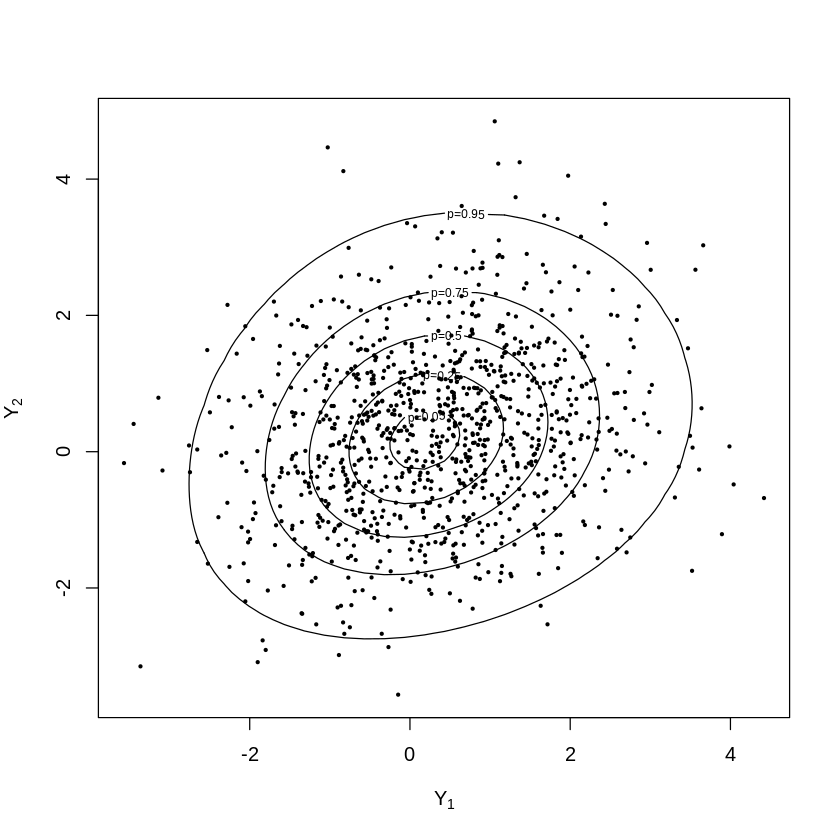

ERROR: Error in elp_plot(dp2 = dp, distribution = "SUT"): object 'nu' not found


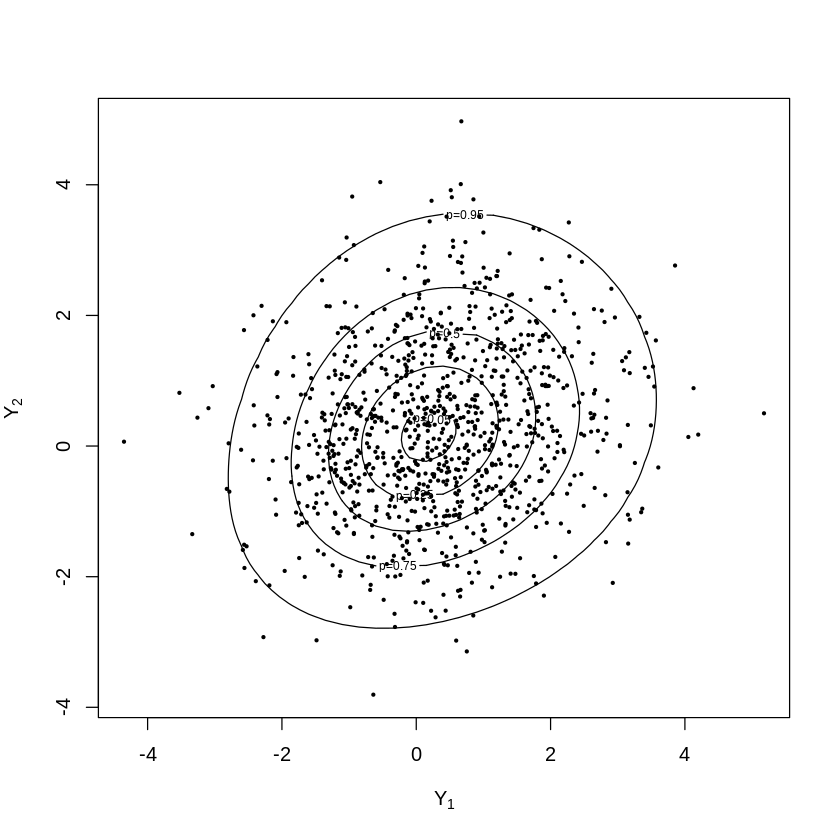

In [7]:
#density to compute the SUT
dsut = function(x,dp){

  xi = dp$xi
  Omega = dp$Omega
  Delta = dp$Delta
  tau = dp$tau
  Gamma = dp$Gamma
  nu = dp$nu

  d = length(xi)
  m = length(tau)
  Omega_inv = solve(Omega)
  quad = t(x - xi)%*%Omega_inv%*%(x - xi)
  alpha = (nu + quad)/(nu + d)
  omega = matrix(0,d,d)
  diag(omega) = sqrt(diag(Omega))
  Omega_bar_inv = omega%*%Omega_inv%*%omega
  mu = (tau + c(t(Delta)%*%Omega_bar_inv%*%solve(omega)%*%(x - xi)))/sqrt(alpha)
  covar = Gamma - t(Delta)%*%Omega_bar_inv%*%Delta
  den = LaplacesDemon::dmvt(x,mu = c(xi),S = Omega, df = nu)*mvtnorm::pmvt(upper = c(mu), delta = rep(0,m), sigma = covar, df = nu+d)/mvtnorm::pmvt(upper = c(tau), delta = rep(0,m), corr = Gamma, df = nu)
  return(den[[1]])
}

#SUT simulator
rsut = function(n,dp){

  xi = dp$xi
  Omega = dp$Omega
  Delta = dp$Delta
  tau = dp$tau
  Gamma = dp$Gamma
  nu = dp$nu

  d= length(xi)
  m =length(tau)

  omega = matrix(0,d,d)
  diag(omega) = sqrt(diag(Omega))
  Omega_bar = solve(omega)%*%Omega%*%solve(omega)
  Gamma_inv = solve(Gamma)

  U_s = tmvtnsim::rtmvt(mean = rep(0,m), sigma = Gamma, nu = nu, n = n, lower = -tau,upper = rep(Inf,m),burn = 1000)
  #compute the quadratic form
  q=c()
  for(i in 1:n){
   if(m > 1){
    quad = t(U_s[i,])%*%Gamma_inv%*%U_s[i,]
   }else{
     quad = U_s[i]%*%Gamma_inv%*%U_s[i]
    }
    q=c(q,quad)
  }

  f = t(Delta%*%Gamma_inv%*%t(U_s))
  w = tmvtnsim::rtmvt(mean = rep(0,d), sigma = Omega_bar - Delta%*%Gamma_inv%*%t(Delta), nu = nu+m, n = n, lower = -Inf,upper = Inf)
  w = sqrt((nu+q)/(nu+m))*w
  z = w + f
  y = xi + z%*%omega
  return(y)
}


elp_plot = function(dp1=NULL,dp2=NULL, parameterization = "A",distribution = "SUN", l = c(0.05,0.25,0.5,0.75,0.95),N_0 = 10^3,draw.points = TRUE,x_lim=NULL,y_lim=NULL,title="", col = c("black","black","black","black","black"),x_lab=bquote(Y[1]),y_lab = bquote(Y[2])){
  #calculate the observed and latent dimensions
  if(is.null(dp2)){
    d = length(dp1$xi)
    m = length(dp1$tau)
  }else{
    d = length(dp2$xi)
    m = length(dp2$tau)
  }
  if(parameterization == "H" & distribution == "SUN"){
    xi =dp1$xi
    psi = dp1$Psi
    H = dp1$H
    tau = dp1$tau
    gamma = dp1$Gamma
    xi.tilde= xi
    w=matrix(0,d,d)
    omega=psi+H%*%gamma%*%t(H)
    diag(w)=sqrt(diag(omega))
    delta=solve(w)%*%H%*%gamma
    #use parameter container
    dp=list(xi=xi.tilde,Omega=omega,Delta=delta,tau=tau, Gamma=gamma)
  }else if(parameterization == "H" & distribution == "SUT")
  {
    xi =dp2$xi
    psi = dp2$Psi
    H = dp2$H
    tau = dp2$tau
    gamma = dp2$Gamma
    nu = dp2$nu
    w=matrix(0,d,d)
    omega=psi+H%*%gamma%*%t(H)
    diag(w)=sqrt(diag(omega))
    delta=solve(w)%*%H%*%gamma
    #print(delta)
    #use parameter container
    dp=list(xi=xi,Omega=omega,Delta=delta,tau=tau, Gamma=gamma, nu = nu)
  }
  else if(parameterization == "A" & distribution == "SUN"){
    dp = dp1
  }
  else{
    dp = dp2
  }
  #start the simulation process
  if (distribution %in% c("SUN","SUT")){
    if (distribution == "SUT"){
      Y_0 = rsut(N_0,dp)
    }
    else
    {
      Y_0 = sn::rsun(N_0,dp=dp)
    }
    y = vector(length = N_0)
    for(i in 1:N_0){
      if (distribution == "SUN"){
        y[i] = -dsun(Y_0[i,],dp=dp)
      }
      else
      {
        if(is.null(nu)){
          stop("VALUE ERROR: NULL DEGREE OF FREEDOM!")
        }
        else{
          y[i] = -dsut(Y_0[i,],dp)
        }
      }
    }
  }else{
    stop("DISTRIBUTION ERROR: NEITHER SUN NOR SUT!")
  }
  prob_st_12 = as.vector(-quantile(y,l))
  #expand the grid
  if(is.null(x_lim)){
    x_lim = c(min(Y_0[,1]),max(Y_0[,1]))
  }
  if(is.null(y_lim)){
    y_lim = c(min(Y_0[,2]),max(Y_0[,2]))
  }
  x = seq(x_lim[1]-1,x_lim[2]+1,0.25)
  y = seq(y_lim[1]-1,y_lim[2]+1,0.1)
  z = expand.grid(x,y)
  h_st = vector()
  for(i in 1:length(z[,1])){
    if (distribution == "SUN"){
      h_st[i] = dsun(as.numeric(z[i,]),dp=dp)
    }else{
      h_st[i] = dsut(as.numeric(z[i,]),dp)
    }
    #print((i/length(z[,1]))*100)
  }
  H_st = matrix(h_st,nrow = length(x),ncol = length(y))
  #setting default bound

  #par(mfrow = c(1,2))
  contour(x,y,H_st,levels = prob_st_12,labels = paste0("p=",l),col = col,add = FALSE,
          xlab = x_lab,ylab = y_lab,main = title,xlim = x_lim,ylim = y_lim,cex.axis = 1)
  if(draw.points == T){
    points(Y_0[,1],Y_0[,2],pch = 20,cex = 0.5)
  }
}

#account for tau not 0
#test for 1 dimensional H
#option not to plot the points
#improve to select parameterization


#200-400 locations genz package for multivariate gaussian mvtnorm

H_to_A = function(dp){


  xi =dp$xi
  psi = dp$Psi
  H = dp$H
  tau = dp$tau
  gamma = dp$Gamma

  d = dim(psi)[1]

  w=matrix(0,d,d)
  omega=psi+H%*%gamma%*%t(H)
  diag(w)=sqrt(diag(omega))
  delta=solve(w)%*%H%*%gamma
  #use parameter container
  dp1=list(xi=xi,Omega=omega,Delta=delta,tau=tau, Gamma=gamma)
  return(dp1)

}



A_to_H = function(dp){

  xi =dp$xi
  Omega = dp$Omega
  Delta = dp$Delta
  tau = dp$tau
  gamma = dp$Gamma

  d = dim(Omega)[1]
  w=matrix(0,d,d)
  diag(w)=sqrt(diag(Omega))

  psi = Omega - H%*%gamma%*%t(H)
  H = w%*%Delta%*%solve(gamma)
  dp1=list(xi=xi,Psi=psi,H=H,tau=tau, Gamma=gamma)
  return(dp1)
}

# #######examples
# library(sn)
# #SUN
# xi=c(0,0)
# Psi=matrix(c(1,0.3,0.3,1),2,2)
# H=matrix(c(1,0,0,1),2,2)
# tau=c(1,1)
# gamma=diag(1,2,2)
# #transform to Azzalini's parameterization
# dp=list(xi=xi,Psi=Psi,H=H,tau=tau, Gamma=gamma)
# dp=H_to_A(dp)

# #SUN:
# #Azzalini's
# elp_plot(dp1=dp)

# #H
# dp=A_to_H(dp)
# elp_plot(dp1=dp,parameterization="H")

# #SUT:
# #Azzalini's
# dp= H_to_A(dp)
# dp$nu=5
# elp_plot(dp2=dp,distribution="SUT")

# #H
# dp=A_to_H(dp)
# dp$nu=5
# elp_plot(dp2=dp,parameterization="H",distribution="SUT")

# #fix window SUT vs SUN compare
# par(mfrow = c(1,2))
# elp_plot(dp2=dp,parameterization="H",distribution="SUT",x_lim = c(-4,5),y_lim=c(-4,5))
# elp_plot(dp1=dp,parameterization="H",distribution="SUN",x_lim = c(-4,5),y_lim=c(-4,5))

# #colors
# par(mfrow=c(1,1))
# elp_plot(dp1=dp,parameterization="H",distribution="SUN",x_lim = c(-4,5),y_lim=c(-4,5),col = c("blue","green","red","orange","black"))



#debug example
# xi=c(0,0)

# Psi=matrix(c(1,0,0,1),2,2)

# H=matrix(c(2,3),2,1)

# tau=0

# Gamma=1

# nu=3

# dp=list(xi=xi,Psi=Psi,H=H,tau=tau, Gamma=Gamma,nu=nu)

# elp_plot(dp2=dp,parameterization="H",distribution="SUT",x_lim = c(-4,15),y_lim=c(-4,20))

In [ ]:
par(mfrow=c(1,1))
elp_plot(dp1=dp,parameterization="H",distribution="SUN",x_lim = c(-4,5),y_lim=c(-4,5),col = c("blue","green","red","orange","black"))

In [3]:
install.packages("sn")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [5]:
install.packages("tmvtnsim")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘RcppArmadillo’




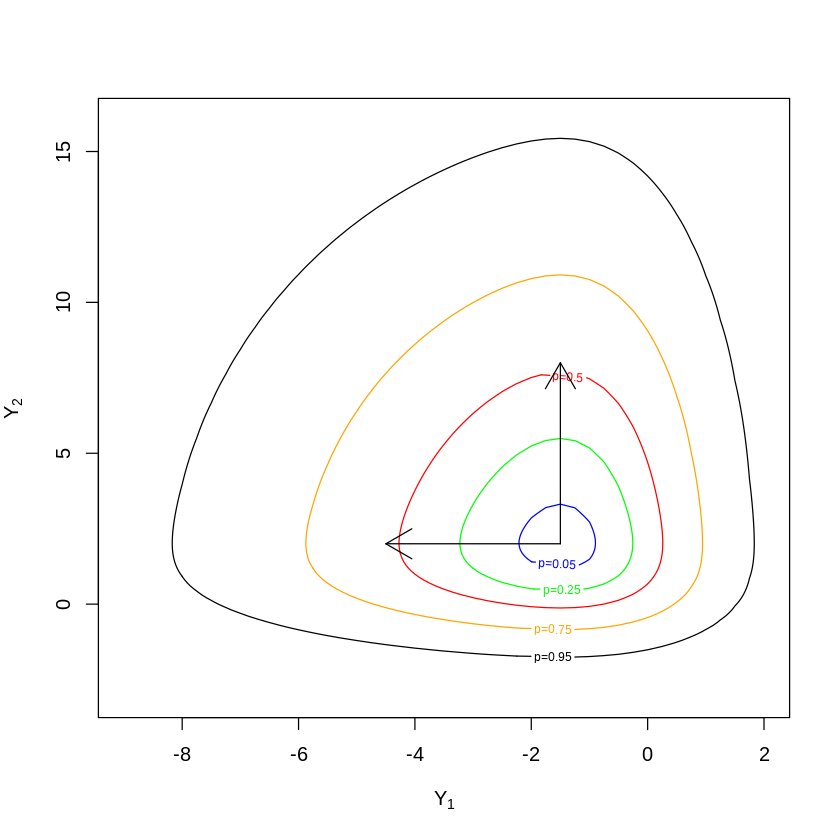

In [32]:

#Figure 1.1
xi=c(0,0)
Psi=matrix(c(1,0,0,1),2,2)
H=matrix(c(-3,0,0,6),2,2)
tau=c(0,0)
Gamma=diag(1,2)
dp=list(xi=xi,Psi=Psi,H=H,tau=tau, Gamma=Gamma)
elp_plot(dp1=dp,parameterization="H",distribution="SUN",x_lim = c(-9,2),y_lim=c(-3,16),col = c("blue","green","red","orange","black"),draw.points = FALSE)
arrows(-1.5,2,-4.5,2) #arrow skewness in Y1 dim
arrows(-1.5,2,-1.5,8) #arrow skewness in Y2 dim

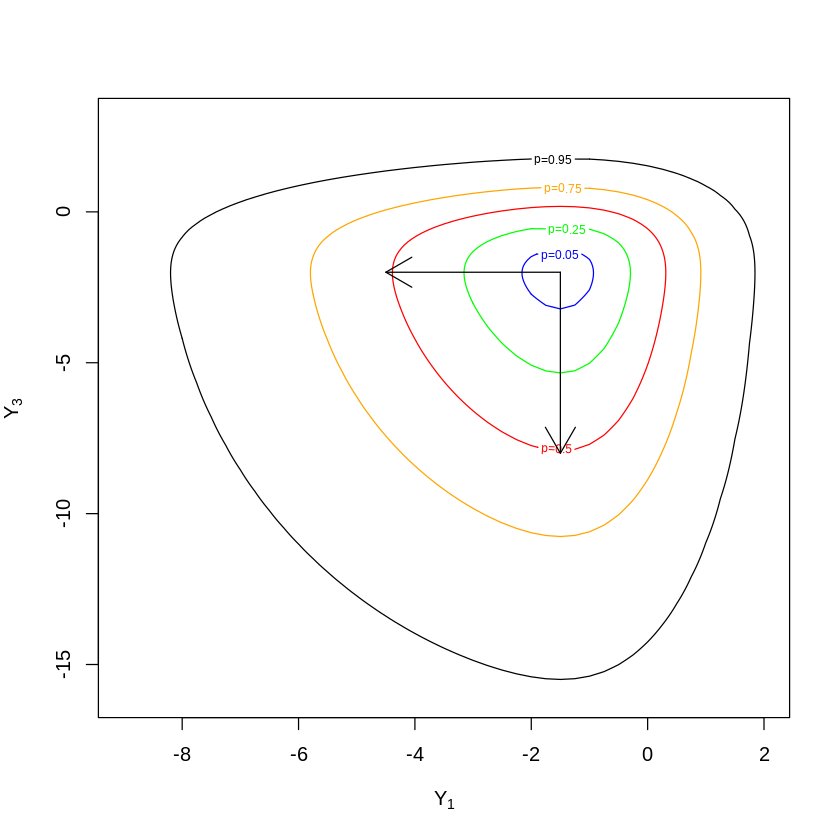

In [35]:
#Figure 1.2
xi=c(0,0)
Psi=matrix(c(1,0,0,1),2,2)
H=matrix(c(-3,0,0,-6),2,2)
tau=c(0,0)
Gamma=diag(1,2)
dp=list(xi=xi,Psi=Psi,H=H,tau=tau, Gamma=Gamma)
elp_plot(dp1=dp,parameterization="H",distribution="SUN",x_lim = c(-9,2),y_lim=c(-16,3),col = c("blue","green","red","orange","black"),draw.points = FALSE,y_lab =expression(Y[3]))
arrows(-1.5,-2,-4.5,-2) #arrow skewness in Y1 dim
arrows(-1.5,-2,-1.5,-8) #arrow skewness in Y3 dim

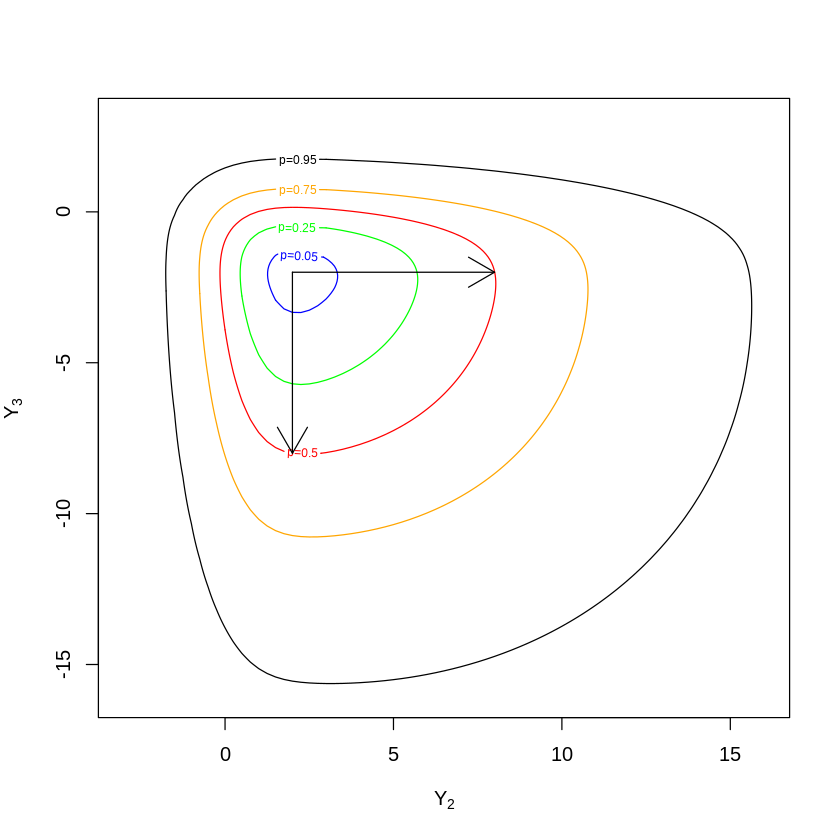

In [39]:
#Figure 1.3
xi=c(0,0)
Psi=matrix(c(1,0,0,1),2,2)
H=matrix(c(6,0,0,-6),2,2)
tau=c(0,0)
Gamma=matrix(c(1,0.2,0.2,1),2,2)
dp=list(xi=xi,Psi=Psi,H=H,tau=tau, Gamma=Gamma)
elp_plot(dp1=dp,parameterization="H",distribution="SUN",x_lim = c(-3,16),y_lim=c(-16,3),col = c("blue","green","red","orange","black"),draw.points = FALSE,y_lab =expression(Y[3]),x_lab = expression(Y[2]))
arrows(2,-2,8,-2) #arrow skewness in Y2 dim
arrows(2,-2,2,-8) #arrow skewness in Y3 dim

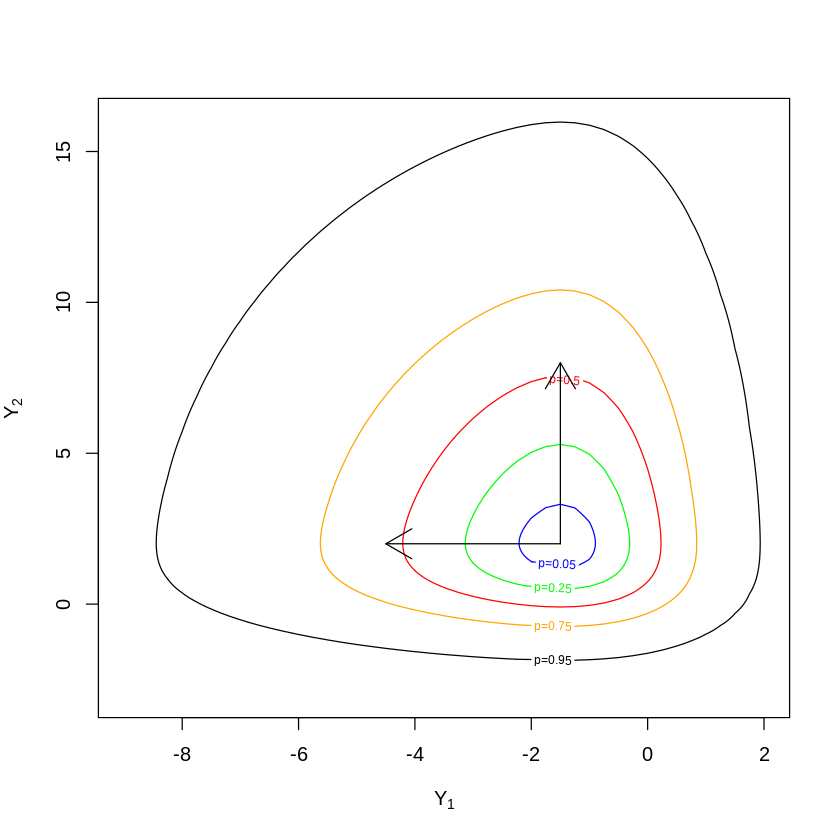

In [40]:

#Figure 2.1
xi=c(0,0)
Psi=matrix(c(1,0,0,1),2,2)
H=matrix(c(-3,0,0,6),2,2)
tau=c(0,0)
Gamma=diag(1,2)
dp=list(xi=xi,Psi=Psi,H=H,tau=tau, Gamma=Gamma)
elp_plot(dp1=dp,parameterization="H",distribution="SUN",x_lim = c(-9,2),y_lim=c(-3,16),col = c("blue","green","red","orange","black"),draw.points = FALSE)
arrows(-1.5,2,-4.5,2) #arrow skewness in Y1 dim
arrows(-1.5,2,-1.5,8) #arrow skewness in Y2 dim

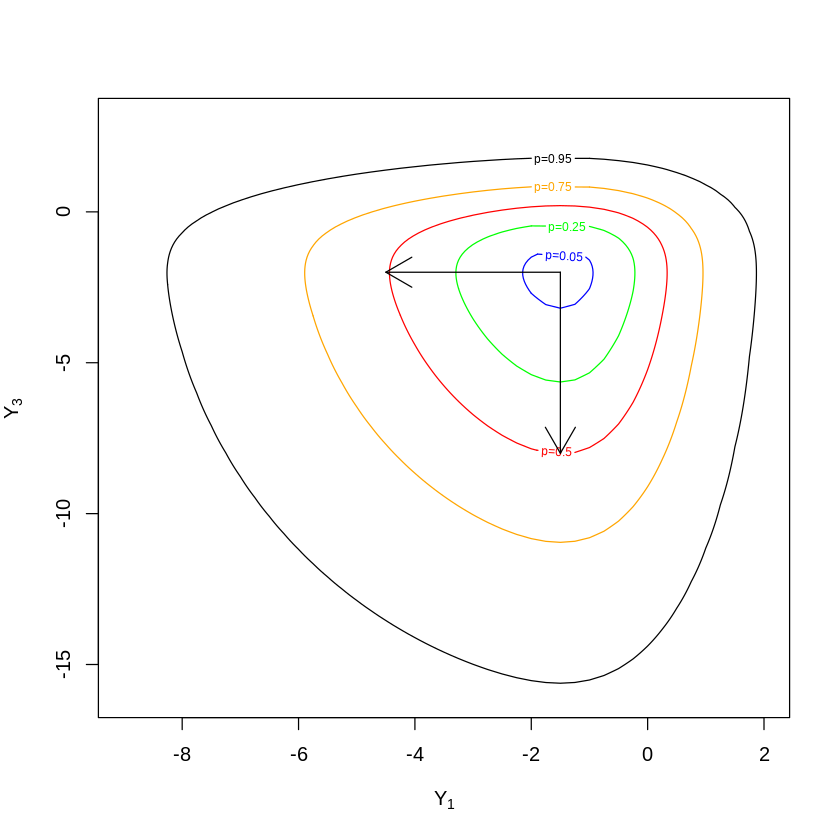

In [41]:
#Figure 2.2
xi=c(0,0)
Psi=matrix(c(1,0,0,1),2,2)
H=matrix(c(-3,0,0,-6),2,2)
tau=c(0,0)
Gamma=diag(1,2)
dp=list(xi=xi,Psi=Psi,H=H,tau=tau, Gamma=Gamma)
elp_plot(dp1=dp,parameterization="H",distribution="SUN",x_lim = c(-9,2),y_lim=c(-16,3),col = c("blue","green","red","orange","black"),draw.points = FALSE,y_lab =expression(Y[3]))
arrows(-1.5,-2,-4.5,-2) #arrow skewness in Y1 dim
arrows(-1.5,-2,-1.5,-8) #arrow skewness in Y3 dim

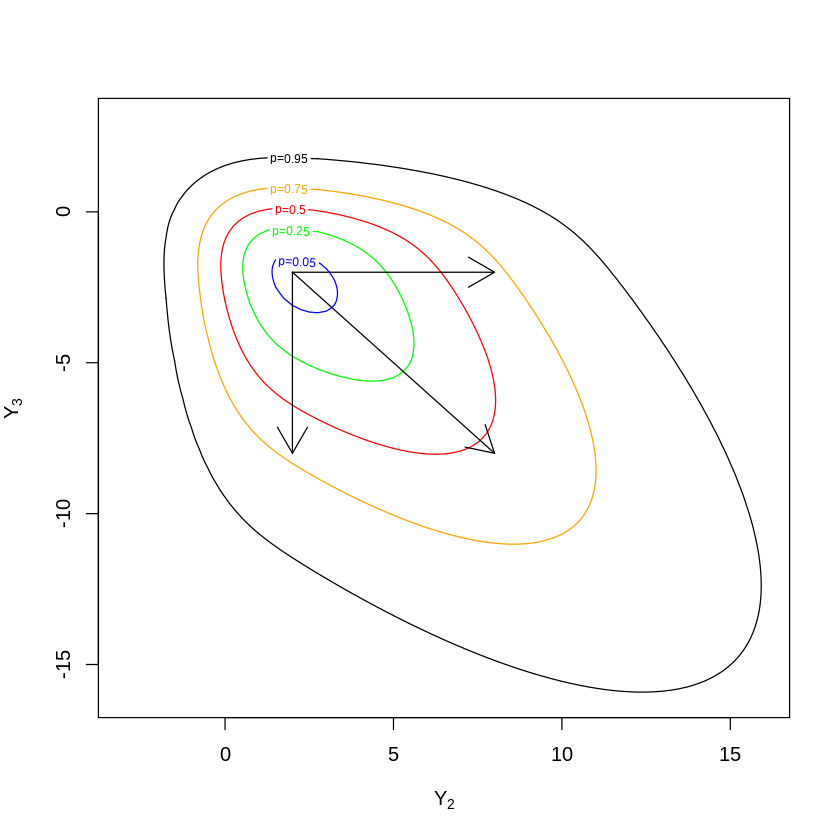

In [43]:
#Figure 1.3
xi=c(0,0)
Psi=matrix(c(1,0,0,1),2,2)
H=matrix(c(6,0,0,-6),2,2)
tau=c(0,0)
Gamma=matrix(c(1,0.8,0.8,1),2,2) #rho = 0.8
dp=list(xi=xi,Psi=Psi,H=H,tau=tau, Gamma=Gamma)
elp_plot(dp1=dp,parameterization="H",distribution="SUN",x_lim = c(-3,16),y_lim=c(-16,3),col = c("blue","green","red","orange","black"),draw.points = FALSE,y_lab =expression(Y[3]),x_lab = expression(Y[2]))
arrows(2,-2,8,-2) #arrow skewness in Y2 dim
arrows(2,-2,2,-8) #arrow skewness in Y3 dim
arrows(2,-2,8,-8) #arrow skewness in joint direction